In [15]:
import pandas as pd
import glob
import re
from transformers import pipeline
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
# Load all CSVs
data_folder = r"C:\Users\kilss\OneDrive\Python\russia-ukraine-sentiment\data"

all_files = glob.glob(f"{data_folder}/*.csv")
df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

print(df.columns)
df.head()

Index(['_type', 'url', 'date', 'content', 'renderedContent', 'id', 'user',
       'replyCount', 'retweetCount', 'likeCount', 'quoteCount',
       'conversationId', 'lang', 'source', 'sourceUrl', 'sourceLabel',
       'outlinks', 'tcooutlinks', 'media', 'retweetedTweet', 'quotedTweet',
       'inReplyToTweetId', 'inReplyToUser', 'mentionedUsers', 'coordinates',
       'place', 'hashtags', 'cashtags', 'Searh'],
      dtype='object')


,_type,url,date,content,renderedContent,id,user,replyCount,retweetCount,likeCount,...,retweetedTweet,quotedTweet,inReplyToTweetId,inReplyToUser,mentionedUsers,coordinates,place,hashtags,cashtags,Searh
0,snscrape.modules.twitter.Tweet,https://twitter.com/donveach/status/1500259722...,2022-03-05 23:59:25+00:00,Is that the same expensive and ineffective bor...,Is that the same expensive and ineffective bor...,1500259722112520194,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,0,1,...,NaN,"{'_type': 'snscrape.modules.twitter.Tweet', 'u...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russian border Ukraine
1,snscrape.modules.twitter.Tweet,https://twitter.com/deliveryman199/status/1500...,2022-03-05 23:58:30+00:00,@DonWaifu @gabehayes @aaronjmate So the Americ...,@DonWaifu @gabehayes @aaronjmate So the Americ...,1500259491232641025,"{'_type': 'snscrape.modules.twitter.User', 'us...",1,0,2,...,NaN,NaN,1.500251e+18,"{'_type': 'snscrape.modules.twitter.User', 'us...","[{'_type': 'snscrape.modules.twitter.User', 'u...",NaN,NaN,NaN,NaN,Russian border Ukraine
2,snscrape.modules.twitter.Tweet,https://twitter.com/JDiozzi/status/15002591158...,2022-03-05 23:57:01+00:00,Maybe if one military unit from Ukraine crosse...,Maybe if one military unit from Ukraine crosse...,1500259115863777280,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russian border Ukraine
3,snscrape.modules.twitter.Tweet,https://twitter.com/Mom2ShihTzu/status/1500258...,2022-03-05 23:55:31+00:00,Volunteers cross Polish border into Ukraine to...,Volunteers cross Polish border into Ukraine to...,1500258740423086083,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russian border Ukraine
4,snscrape.modules.twitter.Tweet,https://twitter.com/SiliconMatters/status/1500...,2022-03-05 23:54:18+00:00,@MarkHertling BUT... theres no Russian aircraf...,@MarkHertling BUT... theres no Russian aircraf...,1500258434414874625,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,1,4,...,NaN,NaN,1.500223e+18,"{'_type': 'snscrape.modules.twitter.User', 'us...","[{'_type': 'snscrape.modules.twitter.User', 'u...",NaN,NaN,NaN,NaN,Russian border Ukraine


In [19]:
# Cleaning the data 
def clean_text(content):
    content = re.sub(r"http\S+|www\S+|https\S+", '', content)
    content = re.sub(r"\@\w+|\#",'', content)
    return content.strip()

df["clean_text"] = df["content"].astype(str).apply(clean_text)
df.head()

,_type,url,date,content,renderedContent,id,user,replyCount,retweetCount,likeCount,...,quotedTweet,inReplyToTweetId,inReplyToUser,mentionedUsers,coordinates,place,hashtags,cashtags,Searh,clean_text
0,snscrape.modules.twitter.Tweet,https://twitter.com/donveach/status/1500259722...,2022-03-05 23:59:25+00:00,Is that the same expensive and ineffective bor...,Is that the same expensive and ineffective bor...,1500259722112520194,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,0,1,...,"{'_type': 'snscrape.modules.twitter.Tweet', 'u...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russian border Ukraine,Is that the same expensive and ineffective bor...
1,snscrape.modules.twitter.Tweet,https://twitter.com/deliveryman199/status/1500...,2022-03-05 23:58:30+00:00,@DonWaifu @gabehayes @aaronjmate So the Americ...,@DonWaifu @gabehayes @aaronjmate So the Americ...,1500259491232641025,"{'_type': 'snscrape.modules.twitter.User', 'us...",1,0,2,...,NaN,1.500251e+18,"{'_type': 'snscrape.modules.twitter.User', 'us...","[{'_type': 'snscrape.modules.twitter.User', 'u...",NaN,NaN,NaN,NaN,Russian border Ukraine,"So the Americans are dressing up as Russians, ..."
2,snscrape.modules.twitter.Tweet,https://twitter.com/JDiozzi/status/15002591158...,2022-03-05 23:57:01+00:00,Maybe if one military unit from Ukraine crosse...,Maybe if one military unit from Ukraine crosse...,1500259115863777280,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russian border Ukraine,Maybe if one military unit from Ukraine crosse...
3,snscrape.modules.twitter.Tweet,https://twitter.com/Mom2ShihTzu/status/1500258...,2022-03-05 23:55:31+00:00,Volunteers cross Polish border into Ukraine to...,Volunteers cross Polish border into Ukraine to...,1500258740423086083,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Russian border Ukraine,Volunteers cross Polish border into Ukraine to...
4,snscrape.modules.twitter.Tweet,https://twitter.com/SiliconMatters/status/1500...,2022-03-05 23:54:18+00:00,@MarkHertling BUT... theres no Russian aircraf...,@MarkHertling BUT... theres no Russian aircraf...,1500258434414874625,"{'_type': 'snscrape.modules.twitter.User', 'us...",0,1,4,...,NaN,1.500223e+18,"{'_type': 'snscrape.modules.twitter.User', 'us...","[{'_type': 'snscrape.modules.twitter.User', 'u...",NaN,NaN,NaN,NaN,Russian border Ukraine,BUT... theres no Russian aircraft flying near ...


In [21]:
#Instatiating the DistilBERT base uncased finetuned SST-2 model 
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Run on a few tweets
results = sentiment_model(df["clean_text"].head(10).tolist())
results

Device set to use cpu


[{'label': 'NEGATIVE', 'score': 0.9988797307014465},
 {'label': 'NEGATIVE', 'score': 0.9992103576660156},
 {'label': 'NEGATIVE', 'score': 0.9991274476051331},
 {'label': 'POSITIVE', 'score': 0.964726448059082},
 {'label': 'NEGATIVE', 'score': 0.9986754059791565},
 {'label': 'NEGATIVE', 'score': 0.9920923113822937},
 {'label': 'NEGATIVE', 'score': 0.9989640712738037},
 {'label': 'POSITIVE', 'score': 0.6660649180412292},
 {'label': 'POSITIVE', 'score': 0.9631554484367371},
 {'label': 'NEGATIVE', 'score': 0.998684823513031}]

In [23]:
#Reduce the number of rows for performance
df_sample = df.sample(n=5000, random_state=42)

In [25]:
#Add predictions to the data frame
df_sample["sentiment"] = df_sample["clean_text"].apply(lambda x: sentiment_model(x)[0]['label'])

In [72]:
# Set a theme for Datavisualisation
sns.set_theme(style="whitegrid", palette="bright")

In [ ]:
# Visualise the sentiment depending on mentioned countries 

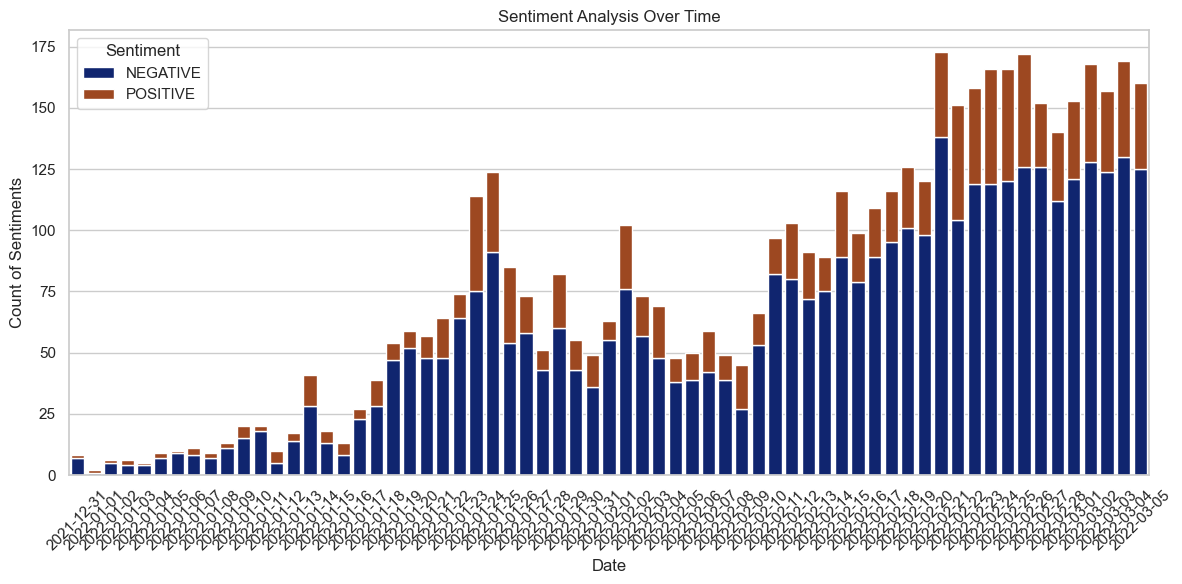

In [80]:
# Group by date and sentiment, then unstack to get the counts
grouped_df = df_sample.groupby([df_sample["date"].dt.date, "sentiment"]).size().unstack(fill_value=0)

# Set the overall figure size
plt.figure(figsize=(12, 6))

# Plot each sentiment category as a stacked bar
bottom = None
for sentiment in grouped_df.columns:
    sns.barplot(x=grouped_df.index, y=grouped_df[sentiment], label=sentiment, bottom=bottom, color=sns.color_palette()[grouped_df.columns.get_loc(sentiment)])
    if bottom is None:
        bottom = grouped_df[sentiment]
    else:
        bottom += grouped_df[sentiment]

# Add a title and axis labels
plt.title("Sentiment Analysis Over Time")
plt.xlabel("Date")
plt.ylabel("Count of Sentiments")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add a legend
plt.legend(title="Sentiment")

# Adjust layout to prevent label/legend overlap
plt.tight_layout()

# Display the plot
plt.show()

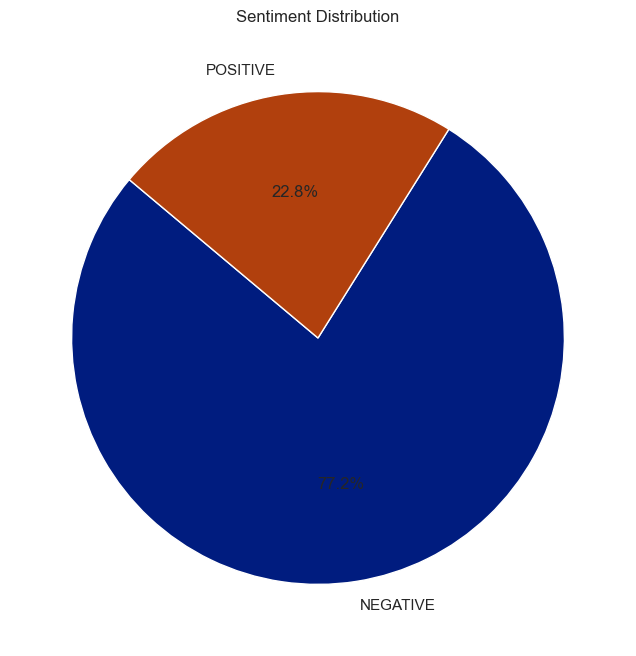

In [82]:
# Count the occurrences of each sentiment
sentiment_counts = df_sample["sentiment"].value_counts()

# Set the overall figure size
plt.figure(figsize=(8, 8))

# Plot the pie chart
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%", startangle=140)

# Add a title
plt.title("Sentiment Distribution")

# Display the plot
plt.show()

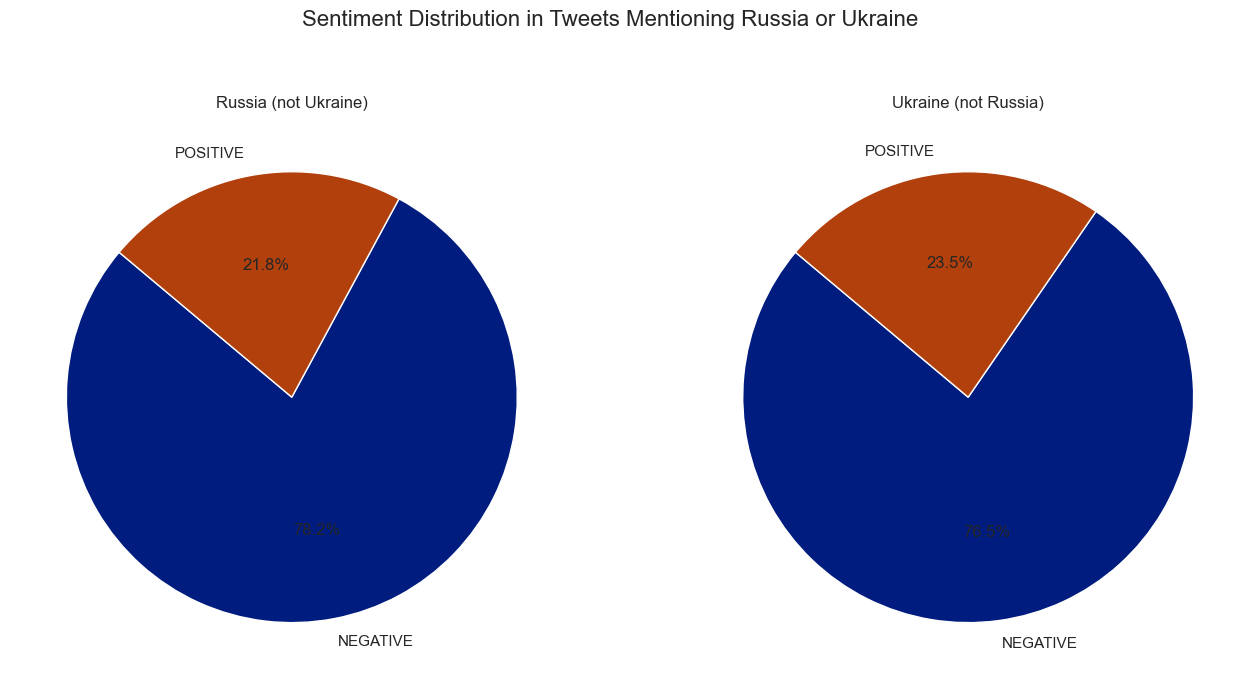

In [84]:
# Filter tweets mentioning "Russia" but not "Ukraine"
russia_tweets = df_sample[df_sample["clean_text"].str.contains("Russia", case=False) & ~df_sample["clean_text"].str.contains("Ukraine", case=False)]

# Filter tweets mentioning "Ukraine" but not "Russia"
ukraine_tweets = df_sample[df_sample["clean_text"].str.contains("Ukraine", case=False) & ~df_sample["clean_text"].str.contains("Russia", case=False)]

# Set up the figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Function to plot pie chart on a specific axis
def plot_sentiment_pie_chart(data, ax, title):
    sentiment_counts = data["sentiment"].value_counts()
    ax.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%", startangle=140)
    ax.set_title(title)

# Plot pie chart for tweets mentioning "Russia" but not "Ukraine"
plot_sentiment_pie_chart(russia_tweets, axes[0], "Russia (not Ukraine)")

# Plot pie chart for tweets mentioning "Ukraine" but not "Russia"
plot_sentiment_pie_chart(ukraine_tweets, axes[1], "Ukraine (not Russia)")

# Add a main title for the entire figure
plt.suptitle("Sentiment Distribution in Tweets Mentioning Russia or Ukraine", fontsize=16)

# Display the plots
plt.show()